# Financial Statement Analysis

## 1. Import Libraries

In [112]:
import pandas as pd

## 2. Load Dataset

In [113]:
df= pd.read_excel(r"C:\Users\personal\Downloads\financial_statement_analysis_training_dataset.xlsx")

In [114]:
df.head()

,TransactionID,Date,Department,Branch,Revenue,COGS,OperatingExpense,Assets,Liabilities,Equity,CashFlow,Customer,Vendor,Status
0,T1005,2025-04-01,SALES,Lagos,-5000.0,9454.04,6720.10,344837.95,103139.14,241698.81,-28516.85,Acme Ltd,vendor b,Pending
1,T1003,16/04/2026,Operations,Lagos,-5000.0,780.56,8700.31,494673.14,295784.04,198889.10,38946.05,NaN,Vendor B,Pending
2,T1004,2025-07-29,Operatons,Abuja,NaN,20481.26,7311.55,127292.96,110275.29,259704.55,-29964.56,Zenith,Vendor B,Cancelled
3,T1005,2025-09-20,HR,lagos,-5000.0,15755.19,3903.54,273817.04,212984.05,60832.99,46980.20,NaN,vendor b,PAID
4,T1006,2025-09-07,sales,lagos,-5000.0,15382.76,1693.80,448887.78,199514.82,249372.96,-31915.41,Globex,Vendor B,PAID


## 3. Initial Data Inspection

The purpose of this section is to understand the structure and quality of the dataset before performing any cleaning or analysis.

In [115]:
df.shape

(800, 14)

In [116]:
df.dtypes

TransactionID        object
Date                 object
Department           object
Branch               object
Revenue             float64
COGS                float64
OperatingExpense    float64
Assets              float64
Liabilities         float64
Equity              float64
CashFlow            float64
Customer             object
Vendor               object
Status               object
dtype: object

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TransactionID     800 non-null    object 
 1   Date              800 non-null    object 
 2   Department        800 non-null    object 
 3   Branch            800 non-null    object 
 4   Revenue           537 non-null    float64
 5   COGS              800 non-null    float64
 6   OperatingExpense  800 non-null    float64
 7   Assets            800 non-null    float64
 8   Liabilities       800 non-null    float64
 9   Equity            800 non-null    float64
 10  CashFlow          800 non-null    float64
 11  Customer          483 non-null    object 
 12  Vendor            800 non-null    object 
 13  Status            800 non-null    object 
dtypes: float64(7), object(7)
memory usage: 87.6+ KB


In [118]:
df.isnull().sum()

TransactionID         0
Date                  0
Department            0
Branch                0
Revenue             263
COGS                  0
OperatingExpense      0
Assets                0
Liabilities           0
Equity                0
CashFlow              0
Customer            317
Vendor                0
Status                0
dtype: int64

In [119]:
df.duplicated().sum()

0

In [120]:
df["TransactionID"].duplicated().sum()

25

In [121]:
df["Department"].nunique()

7

In [122]:
df["Department"].unique()

array(['SALES', 'Operations', 'Operatons', 'HR', ' sales', 'Finance',
       'Sales'], dtype=object)

In [123]:
(df["Revenue"]<0).sum()

278

In [124]:
df["Revenue"].describe

<bound method NDFrame.describe of 0      -5000.00
1      -5000.00
2           NaN
3      -5000.00
4      -5000.00
         ...   
795         NaN
796    -5000.00
797    -5000.00
798    46592.60
799    15615.86
Name: Revenue, Length: 800, dtype: float64>

In [125]:
df["Revenue"].min()

-5000.0

In [126]:
df["Revenue"].max()

49956.82

In [127]:
df[df["TransactionID"].duplicated(keep=False)]

,TransactionID,Date,Department,Branch,Revenue,COGS,OperatingExpense,Assets,Liabilities,Equity,CashFlow,Customer,Vendor,Status
0,T1005,2025-04-01,SALES,Lagos,-5000.00,9454.04,6720.10,344837.95,103139.14,241698.81,-28516.85,Acme Ltd,vendor b,Pending
3,T1005,2025-09-20,HR,lagos,-5000.00,15755.19,3903.54,273817.04,212984.05,60832.99,46980.20,NaN,vendor b,PAID
9,T1005,02/06/2026,HR,lagos,-5000.00,28578.51,1895.43,444666.55,346595.50,98071.05,-24969.57,Globex,VENDOR A,PAID
26,T1005,2025-06-23,Finance,lagos,21728.88,19914.30,4717.67,114378.68,334264.52,266907.04,-37772.15,Globex,Vendor A,Cancelled
49,T1005,06/11/2025,Finance,Abuja,40274.44,22037.84,3478.29,98798.01,247070.26,-148272.25,3704.13,NaN,VENDOR A,Pending
73,T1005,2025-10-12,Operatons,Abuja,-5000.00,16697.59,605.19,231152.74,268442.45,-37289.71,-39204.65,NaN,vendor b,PAID
141,T1005,2026-01-24,Operatons,Abuja,-5000.00,6105.96,2630.39,379649.83,293695.80,95358.06,-717.53,Globex,Vendor B,Paid
152,T1005,14/06/2025,sales,lagos,45557.32,15362.59,7640.42,276658.60,158764.33,117894.27,-32352.73,NaN,Vendor B,Cancelled
179,T1005,2025-01-09,Sales,Lagos,NaN,29804.26,5576.10,170071.63,227790.49,-57718.86,3489.73,Acme Ltd,VENDOR A,paid
188,T1005,2025-09-13,Finance,Port Harcourt,-5000.00,19786.76,9458.94,99531.76,65859.66,33672.10,26068.37,Acme Ltd,vendor b,Paid


In [128]:
df[df["Revenue"].isnull()][["Customer", "Revenue"]]

,Customer,Revenue
2,Zenith,NaN
8,Acme Ltd,NaN
13,Zenith,NaN
14,Acme Ltd,NaN
15,Acme Ltd,NaN
...,...,...
782,NaN,NaN
792,Acme Ltd,NaN
793,NaN,NaN
794,NaN,NaN


In [129]:
df[(df["Revenue"]<0)]["Status"]

0      Pending
1      Pending
3         PAID
4         PAID
5         PAID
        ...   
788       Paid
789    Pending
790    Pending
796       paid
797       Paid
Name: Status, Length: 278, dtype: object

In [130]:
df.head(5)

,TransactionID,Date,Department,Branch,Revenue,COGS,OperatingExpense,Assets,Liabilities,Equity,CashFlow,Customer,Vendor,Status
0,T1005,2025-04-01,SALES,Lagos,-5000.0,9454.04,6720.10,344837.95,103139.14,241698.81,-28516.85,Acme Ltd,vendor b,Pending
1,T1003,16/04/2026,Operations,Lagos,-5000.0,780.56,8700.31,494673.14,295784.04,198889.10,38946.05,NaN,Vendor B,Pending
2,T1004,2025-07-29,Operatons,Abuja,NaN,20481.26,7311.55,127292.96,110275.29,259704.55,-29964.56,Zenith,Vendor B,Cancelled
3,T1005,2025-09-20,HR,lagos,-5000.0,15755.19,3903.54,273817.04,212984.05,60832.99,46980.20,NaN,vendor b,PAID
4,T1006,2025-09-07,sales,lagos,-5000.0,15382.76,1693.80,448887.78,199514.82,249372.96,-31915.41,Globex,Vendor B,PAID


In [131]:
df["Date"].unique()

array(['2025-04-01', '16/04/2026', '2025-07-29', '2025-09-20',
       '2025-09-07', '2025-10-19', '2025-05-25', '26/01/2025',
       '2026-06-19', '02/06/2026', '2026-06-20', '2026-01-12',
       '2025-04-27', '2025-11-23', '2026-01-31', '2026-05-17',
       '2025-06-17', '2026-05-03', '2026-04-16', '2025-04-13',
       '2026-04-22', '03/02/2025', '2025-09-21', '2026-03-21',
       '08/01/2025', '2025-07-06', '2025-06-23', '2025-09-06',
       '2026-04-27', '2026-06-11', '2025-05-18', '2025-06-26',
       '2025-05-23', '2025-03-25', '2026-05-11', '2025-08-21',
       '21/10/2025', '2025-10-16', '2026-05-20', '2025-01-05',
       '2025-11-03', '2026-02-19', '2025-11-08', '25/05/2025',
       '2026-03-16', '2026-01-27', '2026-06-24', '2025-10-17',
       '2025-09-23', '06/11/2025', '13/06/2025', '2025-07-28',
       '2025-08-02', '2025-02-09', '2026-03-17', '2025-12-13',
       '2025-03-19', '20/06/2026', '03/01/2025', '2025-06-21',
       '30/01/2025', '28/01/2025', '2025-11-29', '2025-

## 4. Data Cleaning

The dataset contained inconsistencies in categorical values, formatting, and date representation. These issues were cleaned to improve data quality while preserving the integrity of the original financial records.

In [132]:
df["Date"]=pd.to_datetime(df["Date"], dayfirst=True)

In [133]:
df["Date"]

0     2025-04-01
1     2026-04-16
2     2025-07-29
3     2025-09-20
4     2025-09-07
         ...    
795   2026-05-07
796   2025-11-05
797   2025-07-16
798   2025-07-11
799   2025-12-17
Name: Date, Length: 800, dtype: datetime64[ns]

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   TransactionID     800 non-null    object        
 1   Date              800 non-null    datetime64[ns]
 2   Department        800 non-null    object        
 3   Branch            800 non-null    object        
 4   Revenue           537 non-null    float64       
 5   COGS              800 non-null    float64       
 6   OperatingExpense  800 non-null    float64       
 7   Assets            800 non-null    float64       
 8   Liabilities       800 non-null    float64       
 9   Equity            800 non-null    float64       
 10  CashFlow          800 non-null    float64       
 11  Customer          483 non-null    object        
 12  Vendor            800 non-null    object        
 13  Status            800 non-null    object        
dtypes: datetime64[ns](1), floa

In [135]:
(df["Department"] =="Operatons").sum()

110

In [136]:
df["Department"]=df["Department"].replace("Operatons", "Operations")

In [137]:
df["Department"].unique()

array(['SALES', 'Operations', 'HR', ' sales', 'Finance', 'Sales'],
      dtype=object)

In [138]:
df["Department"]=df["Department"].replace({"SALES": "Sales", "sales" : "Sales"})

In [139]:
df["Department"] = df["Department"].str.strip()

In [140]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [141]:
df["Branch"].unique()

array(['Lagos', 'Abuja', 'lagos', 'Port Harcourt'], dtype=object)

In [142]:
df["Branch"]= df["Branch"].replace("lagos", "Lagos")

In [143]:
(df["COGS"]<0).sum()

0

In [144]:
df["Customer"].unique()

array(['Acme Ltd', nan, 'Zenith', 'Globex'], dtype=object)

In [145]:
df["Status"].unique()

array(['Pending', 'Cancelled', 'PAID', 'Paid', 'paid'], dtype=object)

In [146]:
df["Status"]= df["Status"].replace({"PAID" : "Paid", "paid" : "Paid"})

In [147]:
df["Vendor"].unique()

array(['vendor b', 'Vendor B', 'VENDOR A', 'Vendor A'], dtype=object)

In [148]:
df["Vendor"]= df["Vendor"].replace({"vendor b" : "Vendor B", "VENDOR A" : "Vendor A"})

## 5. Feature Engineering

Additional financial metrics were created to support profitability, liquidity, and leverage analysis.

In [149]:
df["Gross Profit"]=df["Revenue"]-df["COGS"]

In [150]:
df["Operating Profit"]= df["Gross Profit"] - df["OperatingExpense"]

In [151]:
operating_margin= df["Operating Profit"].sum() / df["Revenue"].sum()

In [152]:
operating_margin= round(operating_margin, 2)

In [153]:
operating_margin

-1.06

In [154]:
df["Working Capital"]= df["Assets"] - df["Liabilities"]

In [155]:
current_ratio= round(df["Assets"].sum() / df["Liabilities"].sum(),2)
current_ratio

1.26

In [156]:
debt_to_equity_ratio= round(df["Liabilities"].sum() / df["Equity"].sum(),2)
debt_to_equity_ratio

3.4

# 6. Exploratory Data Analysis

## Business Question 1

### Which department contributes the most to profitability?

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
df.groupby("Department")["Gross Profit"].sum()

Department
Finance       -210670.02
HR            -592294.60
Operations    -698354.97
Sales        -1318207.05
sales          -75112.52
Name: Gross Profit, dtype: float64

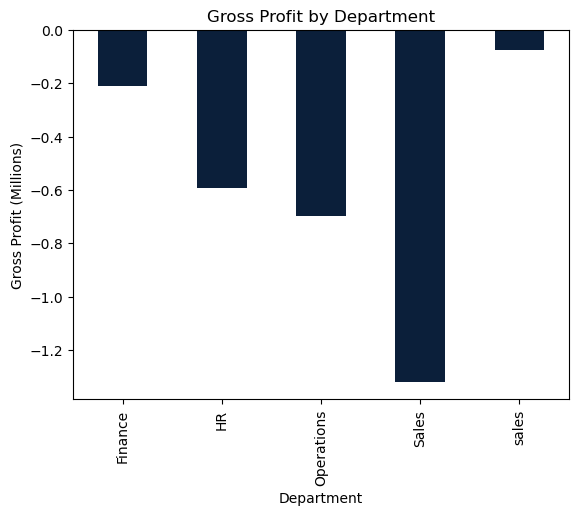

In [159]:
gross_profit = df.groupby("Department")["Gross Profit"].sum() / 1000000

gross_profit.plot(
    kind="bar",
    color="#0B1F3A"
)

plt.title("Gross Profit by Department")
plt.ylabel("Gross Profit (Millions)")
plt.savefig(
    r"C:\Users\personal\Downloads\Gross_Profit_by_Department.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [160]:
df.head(5)

,TransactionID,Date,Department,Branch,Revenue,COGS,OperatingExpense,Assets,Liabilities,Equity,CashFlow,Customer,Vendor,Status,Gross Profit,Operating Profit,Working Capital
0,T1005,2025-04-01,Sales,Lagos,-5000.0,9454.04,6720.10,344837.95,103139.14,241698.81,-28516.85,Acme Ltd,Vendor B,Pending,-14454.04,-21174.14,241698.81
1,T1003,2026-04-16,Operations,Lagos,-5000.0,780.56,8700.31,494673.14,295784.04,198889.10,38946.05,NaN,Vendor B,Pending,-5780.56,-14480.87,198889.10
2,T1004,2025-07-29,Operations,Abuja,NaN,20481.26,7311.55,127292.96,110275.29,259704.55,-29964.56,Zenith,Vendor B,Cancelled,NaN,NaN,17017.67
3,T1005,2025-09-20,HR,Lagos,-5000.0,15755.19,3903.54,273817.04,212984.05,60832.99,46980.20,NaN,Vendor B,Paid,-20755.19,-24658.73,60832.99
4,T1006,2025-09-07,sales,Lagos,-5000.0,15382.76,1693.80,448887.78,199514.82,249372.96,-31915.41,Globex,Vendor B,Paid,-20382.76,-22076.56,249372.96


In [161]:
df["Gross_margin"]= (df["Gross Profit"]/ df["Revenue"] ) * 100
df["Gross_margin"]

0      289.080800
1      115.611200
2             NaN
3      415.103800
4      407.655200
          ...    
795           NaN
796    484.125400
797    423.262200
798     98.479394
799     88.462307
Name: Gross_margin, Length: 800, dtype: float64

In [162]:
df[df["Gross_margin"]<0]

,TransactionID,Date,Department,Branch,Revenue,COGS,OperatingExpense,Assets,Liabilities,Equity,CashFlow,Customer,Vendor,Status,Gross Profit,Operating Profit,Working Capital,Gross_margin
6,T1008,2025-05-25,Sales,Lagos,6132.42,22242.10,9543.65,380170.90,130317.98,249852.92,-8388.90,Acme Ltd,Vendor A,Paid,-16109.68,-25653.33,249852.92,-262.696945
23,T1025,2026-03-21,Finance,Port Harcourt,20622.93,25142.45,6531.62,337645.81,355385.35,-17739.54,38963.29,NaN,Vendor B,Cancelled,-4519.52,-11051.14,-17739.54,-21.915024
27,T1029,2025-09-06,sales,Lagos,3531.20,25676.51,3153.56,254999.49,148959.27,245381.33,43571.54,Zenith,Vendor B,Paid,-22145.31,-25298.87,106040.22,-627.132703
32,T1034,2025-05-23,sales,Port Harcourt,3938.40,23933.94,1486.45,26883.84,160214.20,-133330.36,3107.43,NaN,Vendor B,Paid,-19995.54,-21481.99,-133330.36,-507.707191
34,T1036,2026-05-11,Operations,Abuja,12693.53,23563.06,1888.86,364671.83,157584.76,207087.07,-40851.50,NaN,Vendor A,Paid,-10869.53,-12758.39,207087.07,-85.630475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,T1728,2025-05-30,sales,Abuja,14319.63,20768.57,7760.89,391169.19,10265.81,380903.38,-23559.55,Acme Ltd,Vendor A,Paid,-6448.94,-14209.83,380903.38,-45.035661
737,T1739,2026-03-11,HR,Lagos,5075.09,13896.21,3070.31,31997.19,388033.24,-356036.05,11784.08,NaN,Vendor B,Paid,-8821.12,-11891.43,-356036.05,-173.812090
747,T1749,2026-01-11,Sales,Abuja,9313.06,18510.95,2744.24,368229.26,215758.45,152470.81,-31556.58,NaN,Vendor A,Pending,-9197.89,-11942.13,152470.81,-98.763350
767,T1769,2025-02-28,Sales,Abuja,1004.44,23507.39,3367.75,378977.36,301173.29,77804.07,16368.55,NaN,Vendor A,Paid,-22502.95,-25870.70,77804.07,-2240.347856


In [163]:
df.groupby("Department")["Gross_margin"].mean().round(2)

Department
Finance       219.02
HR            234.75
Operations    185.34
Sales         209.38
sales         176.93
Name: Gross_margin, dtype: float64

In [164]:
df.groupby("Department")["Revenue"].sum()

Department
Finance        940933.59
HR             730390.56
Operations    1661962.79
Sales         1160405.60
sales          822692.03
Name: Revenue, dtype: float64

In [165]:
df.groupby("Department")["COGS"].sum()

Department
Finance       1804191.68
HR            1986743.83
Operations    3362192.83
Sales         3529998.14
sales         1499554.41
Name: COGS, dtype: float64

In [166]:
df.groupby("Department")["Gross Profit"].sum()

Department
Finance       -210670.02
HR            -592294.60
Operations    -698354.97
Sales        -1318207.05
sales          -75112.52
Name: Gross Profit, dtype: float64

In [167]:
revenue_vs_cogs=df.groupby("Department")[["Revenue","COGS"]].sum()
revenue_vs_cogs

,Revenue,COGS
Department,,
Finance,940933.59,1804191.68
HR,730390.56,1986743.83
Operations,1661962.79,3362192.83
Sales,1160405.60,3529998.14
sales,822692.03,1499554.41


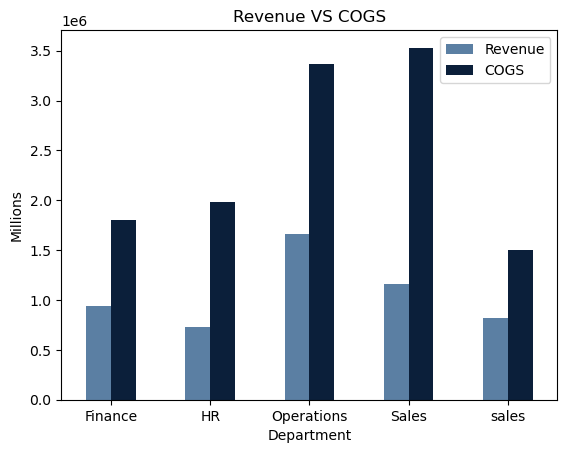

In [168]:
revenue_vs_cogs.plot(kind="bar",color=["#5B7FA3", "#0B1F3A"])

plt.ylabel("Millions")
plt.xticks(rotation=0)
plt.title("Revenue VS COGS")
plt.savefig(
    r"C:\Users\personal\Downloads\Revenue_VS_COGS.png",
    dpi=300,
    bbox_inches="tight"
)

### Findings

- All departments reported negative Gross Profit.
- Sales recorded the largest gross loss.
- Finance recorded the smallest gross loss.
- Revenue was consistently lower than COGS across all departments, indicating a company-wide profitability issue rather than a department-specific problem.

## Business Question 2

### How has gross profitability changed over time?

In [169]:
year=df["Date"].dt.year

In [170]:
year.unique()

array([2025, 2026], dtype=int64)

In [171]:
df["Year"]=df["Date"].dt.year

In [172]:
df["Month_Number"] = df["Date"].dt.month

In [173]:
df["Month"]=df["Date"].dt.month_name()

In [174]:
df["Month"].unique()

array(['April', 'July', 'September', 'October', 'May', 'January', 'June',
       'November', 'February', 'March', 'August', 'December'],
      dtype=object)

In [175]:
profit_trend = (
    df.groupby(["Year", "Month_Number", "Month"])["Gross Profit"]
      .sum()
)

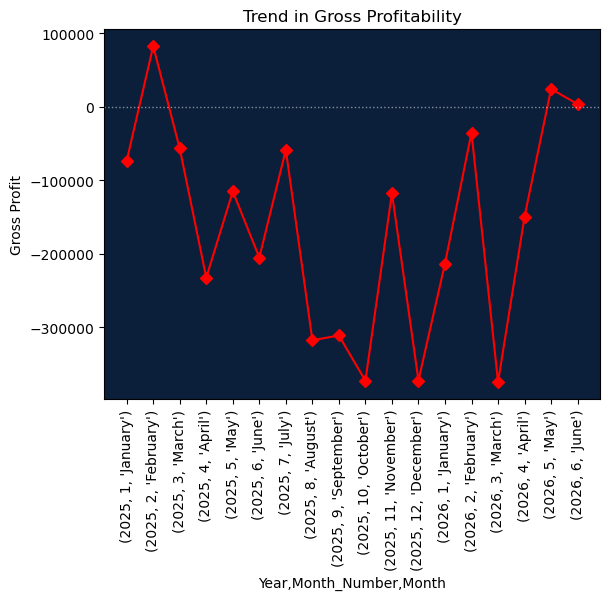

In [176]:
profit_trend.plot(kind="line",color="red", marker="D")
#had to force matplotlip to show be every month in every year that exists
plt.xticks(ticks=range(len(profit_trend.index)), labels=profit_trend.index, rotation=90)
plt.axhline(y=0, color="white", linestyle=":", linewidth=1, alpha=0.5)
plt.gca().set_facecolor("#0B1F3A")
plt.ylabel("Gross Profit")
plt.title("Trend in Gross Profitability")
plt.savefig(
    r"C:\Users\personal\Downloads\Trend_in_Gross_Profitability.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [177]:
df[(df["Year"]==2025) & (df["Month"].isin(["July", "August"]))].groupby("Month")[["Revenue", "COGS", "Gross Profit"]].sum()

,Revenue,COGS,Gross Profit
Month,,,
August,298156.48,954061.07,-317684.06
July,258153.78,598227.77,-58405.84


In [178]:
df[["Revenue", "COGS", "Gross Profit"]]

,Revenue,COGS,Gross Profit
0,-5000.00,9454.04,-14454.04
1,-5000.00,780.56,-5780.56
2,NaN,20481.26,NaN
3,-5000.00,15755.19,-20755.19
4,-5000.00,15382.76,-20382.76
...,...,...,...
795,NaN,27415.16,NaN
796,-5000.00,19206.27,-24206.27
797,-5000.00,16163.11,-21163.11
798,46592.60,708.49,45884.11


### Findings

- Gross Profit remained negative for most of the reporting period.
- The first major decline occurred in August 2025.
- The deepest losses occurred around October and December 2025, followed by another decline in March 2026.
- Profitability gradually recovered between May and June 2026.

## Business Question 3

### Are all branches performing equally, or are some branches outperforming others?

In [179]:
df.groupby("Branch")["Gross_margin"].mean()

Branch
Abuja            171.105973
Lagos            214.434263
Port Harcourt    217.013296
Name: Gross_margin, dtype: float64

In [180]:
df.groupby("Branch")["Revenue"].sum()

Branch
Abuja            1670749.37
Lagos            2404936.47
Port Harcourt    1240698.73
Name: Revenue, dtype: float64

In [181]:
df[(df["Gross Profit"]<0) & (df["Revenue"] < 0)]

,TransactionID,Date,Department,Branch,Revenue,COGS,OperatingExpense,Assets,Liabilities,Equity,...,Customer,Vendor,Status,Gross Profit,Operating Profit,Working Capital,Gross_margin,Year,Month_Number,Month
0,T1005,2025-04-01,Sales,Lagos,-5000.0,9454.04,6720.10,344837.95,103139.14,241698.81,...,Acme Ltd,Vendor B,Pending,-14454.04,-21174.14,241698.81,289.0808,2025,4,April
1,T1003,2026-04-16,Operations,Lagos,-5000.0,780.56,8700.31,494673.14,295784.04,198889.10,...,NaN,Vendor B,Pending,-5780.56,-14480.87,198889.10,115.6112,2026,4,April
3,T1005,2025-09-20,HR,Lagos,-5000.0,15755.19,3903.54,273817.04,212984.05,60832.99,...,NaN,Vendor B,Paid,-20755.19,-24658.73,60832.99,415.1038,2025,9,September
4,T1006,2025-09-07,sales,Lagos,-5000.0,15382.76,1693.80,448887.78,199514.82,249372.96,...,Globex,Vendor B,Paid,-20382.76,-22076.56,249372.96,407.6552,2025,9,September
5,T1007,2025-10-19,HR,Lagos,-5000.0,8776.90,8216.52,230142.96,14006.96,216136.00,...,Acme Ltd,Vendor A,Paid,-13776.90,-21993.42,216136.00,275.5380,2025,10,October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788,T1790,2025-05-15,Operations,Lagos,-5000.0,29866.51,4290.16,11030.94,355647.45,-344616.51,...,NaN,Vendor B,Paid,-34866.51,-39156.67,-344616.51,697.3302,2025,5,May
789,T1791,2026-04-30,Operations,Lagos,-5000.0,11601.69,5429.42,358911.31,195486.02,163425.29,...,Acme Ltd,Vendor A,Pending,-16601.69,-22031.11,163425.29,332.0338,2026,4,April
790,T1792,2026-03-27,HR,Abuja,-5000.0,12304.93,9295.39,149584.74,180433.67,-30848.93,...,Globex,Vendor A,Pending,-17304.93,-26600.32,-30848.93,346.0986,2026,3,March
796,T1798,2025-11-05,HR,Port Harcourt,-5000.0,19206.27,2817.11,154620.23,393605.06,87203.47,...,NaN,Vendor B,Paid,-24206.27,-27023.38,-238984.83,484.1254,2025,11,November


In [182]:
branch_gp = df.groupby("Branch")["Gross Profit"].sum()
branch_gp

Branch
Abuja            -274922.28
Lagos           -1921542.37
Port Harcourt    -698174.51
Name: Gross Profit, dtype: float64

In [183]:
branch_gp_percent =round((branch_gp / branch_gp.sum()) * 100, 2)
# This calculates branch contributing heavily to gross loss
branch_gp_percent

Branch
Abuja             9.50
Lagos            66.38
Port Harcourt    24.12
Name: Gross Profit, dtype: float64

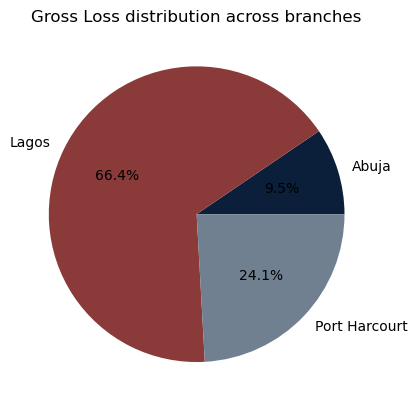

In [184]:
branch_gp_percent.plot(kind = "pie", autopct="%1.1f%%",colors=["#0B1F3A", "#8B3A3A", "#708090"])
plt.title("Gross Loss distribution across branches")
plt.ylabel("")
plt.savefig(
    r"C:\Users\personal\Downloads\Branch_Gross_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

Who are the company's most valuable customers based on revenue contribution?

### Findings

- Branches contribute differently to the company's overall Gross Profit (Loss).
- The analysis highlights which branches account for a larger share of total losses, helping management identify areas that require operational review.

## Business Question 4

### Who are the company's most valuable customers based on revenue contribution?

In [185]:
customer_revenue=df.groupby("Customer")["Revenue"].sum()
customer_revenue

Customer
Acme Ltd    1228250.08
Globex       955135.67
Zenith      1204810.29
Name: Revenue, dtype: float64

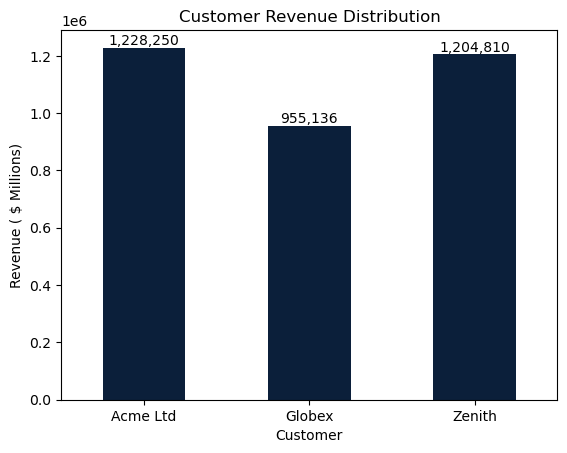

In [186]:
ax= customer_revenue.plot(kind="bar", color= "#0B1F3A")
ax.bar_label(
    ax.containers[0],
    labels=[f"{x:,.0f}" for x in customer_revenue]
)
plt.ylabel("Revenue ( $ Millions)")
plt.xticks(rotation=0)
plt.title("Customer Revenue Distribution")
plt.savefig(
    r"C:\Users\personal\Downloads\Customer_Revenue_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

### Findings

- Revenue is relatively evenly distributed across the company's three customers.
- No single customer dominates total revenue.
- However, with only three customers, the business remains highly dependent on a small customer base.

## Business Question 5

### How is procurement spending distributed across vendors?

In [187]:
Vendor_dist=df.groupby("Vendor")["COGS"].sum()
Vendor_dist
# i wanted to include comma without decimals
Vendor_dist.map(lambda x: f"{x:,.0f}")

Vendor
Vendor A    6,229,876
Vendor B    5,952,805
Name: COGS, dtype: object

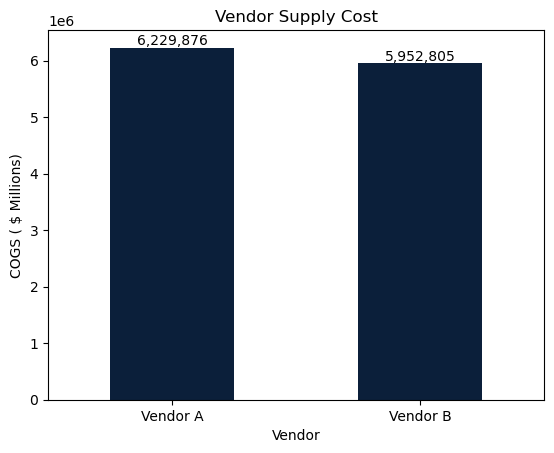

In [188]:
ax= Vendor_dist.plot(kind="bar", color= "#0B1F3A")
ax.bar_label(
    ax.containers[0],
    labels=[f"{x:,.0f}" for x in Vendor_dist]
)
plt.ylabel("COGS ( $ Millions)")
plt.xticks(rotation=0)
plt.title("Vendor Supply Cost")
plt.savefig(
    r"C:\Users\personal\Downloads\Vendor_Supply_Cost.png",
    dpi=300,
    bbox_inches="tight"
)

### Findings

- Procurement spending is relatively balanced between Vendor A and Vendor B.
- The company does not appear to rely heavily on a single supplier, reducing supplier concentration risk.

# 7. Conclusion

### Summary

This analysis identified company-wide profitability challenges driven by procurement costs consistently exceeding revenue. Although revenue is relatively balanced across departments, customers, and vendors, the business continues to experience sustained gross losses throughout most of the reporting period.

### Recommendations

- Review procurement and supplier costs to reduce Cost of Goods Sold.
- Investigate the business changes that occurred around August 2025, when profitability began to decline significantly.
- Expand the customer base to reduce reliance on only three customers.
- Continue monitoring branch performance to identify operational improvement opportunities.